# Brdu cellcounts

In [1]:
import sys
import os
sys.path.append('/home/jovyan/projects/cellcount/')
#print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

/home/jovyan/projects/cellcount


In [83]:
path2kdrive = "/home/jovyan/kDrive"
path2file = os.path.join(path2kdrive, "cellcount/data/brdu/Cellcount_BrdU.xlsx")
print(path2file)
path2save = os.path.join(path2kdrive, "cellcount/data/brdu/brdu_fluorescent_ratio.png")
print(path2save)

/home/jovyan/kDrive/cellcount/data/brdu/Cellcount_BrdU.xlsx
/home/jovyan/kDrive/cellcount/data/brdu/brdu_fluorescent_ratio.png


Import spreadsheet with data and compute ratio of fuorescent cells:

In [84]:
df = pd.read_excel(path2file, engine="openpyxl")
df['ratio']= df.Fluo/df.Total
df

,Stage,Total,Fluo,ratio
0,E7-1,521,136,0.261036
1,E7-2,388,107,0.275773
2,E7-3,296,83,0.280405
3,E7-4,221,62,0.280543
4,E7-5,259,76,0.293436
5,E8-1,210,39,0.185714
6,E8-2,187,47,0.251337
7,E8-3,132,27,0.204545
8,E8-6,254,55,0.216535
9,E8-9,233,60,0.257511


Compute the mean and standard deviation for each development stadium:

In [85]:
stadii = ['E7', 'E8', 'E9']
means = []
stds = []
for s in stadii:
    subdf = df[df['Stage'].str.contains(s)]
    #print(subdf)
    means.append(subdf.mean()['ratio'] * 100)
    stds.append(subdf.std()['ratio'] * 100)

In [86]:
print(means)
print(stds)

[27.823886989469234, 22.312856026801242, 9.144108004852706]
[1.165082271088755, 3.068579880726675, 1.413603386060089]


Create bar plot with error bars:

In [87]:
SMALL_SIZE = 14
MEDIUM_SIZE = 16
#BIG_SIZE = 20
#WEIGHT = 'bold'
WEIGHT = 'normal'
plt.rc('font', size=SMALL_SIZE, weight=WEIGHT)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE, titleweight='normal')     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE, labelweight=WEIGHT)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
#plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Calibri']

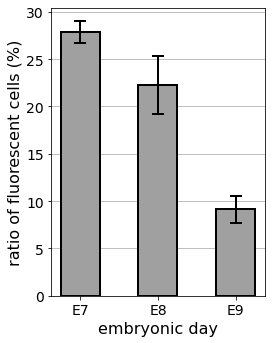

In [88]:
x_pos = np.arange(len(stadii))
scale_factor = 1
fig, ax = plt.subplots(figsize=(scale_factor * 4, scale_factor * 5))
ax.yaxis.grid(True, zorder=0)
ax.bar(x_pos, means, width=0.5, yerr=stds, align='center', alpha=1, color='#A0A0A0', edgecolor='black', linewidth='2',
capsize=10, zorder=3, error_kw={'capsize': 6, 'elinewidth': 2, 'capthick': 2, 'ecolor':'black'})
ax.set_xlabel('embryonic day')
ax.set_ylabel('ratio of fluorescent cells (%)')
ax.set_xticks(x_pos)
ax.set_xticklabels(stadii)
#ax.set_title('')

# Save the figure and show
plt.tight_layout()
plt.savefig(path2save, dpi=2*96, facecolor='white')
plt.show()